# Ablation Study (Colleague Run) — Inference + Plots and Conclusions
In this notebook we run an **ablation study** to understand which input features matter most for our final regression pipeline. We compare a **Baseline** model (all features) against multiple variants where we remove **one feature at a time** (“w/o feature”). Performance is evaluated with **K-fold cross-validation**, and we report **RMSE** (lower is better).  

For each feature removal we compute:  
- **Mean RMSE ± variability across folds**,  
- **Paired significance tests vs. the baseline** (with multiple-testing correction),  
- A **feature-importance ranking** based on how much RMSE worsens when the feature is removed,  
- And plots that summarize impact and stability across folds.

In [1]:
import os
import ast
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# -----------------------
# Paths / outputs
# -----------------------
INPUT_CSV = "ablation_results.csv"  
OUT_STATS = "ablation_summary_stats.csv"
OUT_SIG   = "ablation_significance_tests.csv"
OUT_IMP   = "ablation_feature_importance.csv"

PLOTS_DIR = "results/ablation/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

BASELINE_NAME = "Baseline"
ALPHA = 0.05
CORRECTION = "holm"  # multiple testing correction

# Primary metric (RMSE only for this colleague schema)
PRIMARY_METRIC = "rmse"


In [2]:
# -----------------------
# Load colleague ablation_results.csv and reconstruct fold-level rows
# -----------------------
raw_df = pd.read_csv(INPUT_CSV)

# Normalize naming to match the rest of the pipeline
if "model_variant" not in raw_df.columns and "model" in raw_df.columns:
    raw_df = raw_df.rename(columns={"model": "model_variant"})

raw_df["features_removed"] = (
    raw_df["features_removed"]
      .fillna("none")
      .astype(str)
      .str.strip()
)
raw_df.loc[raw_df["features_removed"].str.lower().isin(["none", "nan", ""]), "features_removed"] = "none"

# Parse fold_scores from string -> list
def _parse_scores(x):
    if isinstance(x, list):
        return x
    return ast.literal_eval(str(x))

raw_df["fold_scores"] = raw_df["fold_scores"].apply(_parse_scores)

# Explode to fold-level
results_df = raw_df.explode("fold_scores").reset_index(drop=True)
results_df["fold"] = results_df.groupby(["model_variant", "features_removed"]).cumcount() + 1
results_df = results_df.rename(columns={"fold_scores": "rmse"})
results_df["rmse"] = pd.to_numeric(results_df["rmse"], errors="coerce")

print("Fold-level results_df shape:", results_df.shape)
print("Columns:", results_df.columns.tolist())
print("# folds:", results_df["fold"].nunique(), "folds:", sorted(results_df["fold"].unique()))
print("Variants:", results_df["model_variant"].unique().tolist())
results_df.head()


Fold-level results_df shape: (65, 7)
Columns: ['model_variant', 'features_removed', 'num_features', 'mean_rmse', 'std_rmse', 'rmse', 'fold']
# folds: 5 folds: [1, 2, 3, 4, 5]
Variants: ['Baseline', 'w/o Brand', 'w/o model', 'w/o year', 'w/o transmission', 'w/o mileage', 'w/o fuelType', 'w/o tax', 'w/o mpg', 'w/o engineSize', 'w/o paintQuality%', 'w/o previousOwners', 'w/o hasDamage']


,model_variant,features_removed,num_features,mean_rmse,std_rmse,rmse,fold
0,Baseline,none,12,2804.238196,252.06428,2569.553567,1
1,Baseline,none,12,2804.238196,252.06428,2795.995152,2
2,Baseline,none,12,2804.238196,252.06428,3228.380945,3
3,Baseline,none,12,2804.238196,252.06428,2895.593102,4
4,Baseline,none,12,2804.238196,252.06428,2531.668216,5


In [3]:
# -----------------------
# Summary statistics (mean/std/CI) per variant
# -----------------------
def mean_ci(values, conf=0.95):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    n = len(values)
    if n == 0:
        return np.nan, np.nan, np.nan
    m = float(np.mean(values))
    if n == 1:
        return m, np.nan, np.nan
    se = float(np.std(values, ddof=1) / np.sqrt(n))
    tcrit = float(stats.t.ppf((1 + conf) / 2.0, df=n - 1))
    half = tcrit * se
    return m, m - half, m + half

rows = []
for (mv, fr), g in results_df.groupby(["model_variant", "features_removed"], dropna=False):
    vals = g["rmse"].values
    m = float(np.mean(vals))
    s = float(np.std(vals, ddof=1)) if len(vals) > 1 else np.nan
    m_ci, lo, hi = mean_ci(vals, conf=0.95)
    rows.append({
        "model_variant": mv,
        "features_removed": fr,
        "rmse_mean": m,
        "rmse_std": s,
        "rmse_ci_low": lo,
        "rmse_ci_high": hi,
        "n_folds": int(len(vals)),
    })

stats_df = pd.DataFrame(rows).sort_values(["model_variant", "features_removed"]).reset_index(drop=True)
stats_df.to_csv(OUT_STATS, index=False)

stats_df.head()


,model_variant,features_removed,rmse_mean,rmse_std,rmse_ci_low,rmse_ci_high,n_folds
0,Baseline,none,2804.238196,281.816433,2454.316878,3154.159515,5
1,w/o Brand,Brand,2808.611430,279.468537,2461.605409,3155.617452,5
2,w/o engineSize,engineSize,3296.737031,267.463029,2964.637817,3628.836244,5
3,w/o fuelType,fuelType,2775.781370,273.167973,2436.598532,3114.964208,5
4,w/o hasDamage,hasDamage,2804.048388,271.798812,2466.565589,3141.531188,5


In [4]:
# -----------------------
# Significance tests: paired t-test vs baseline (per fold), Holm correction
# -----------------------
def adjust_pvalues(pvals, method="holm"):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    if m == 0:
        return pvals
    if method == "none":
        return pvals
    if method == "bonferroni":
        return np.clip(pvals * m, 0, 1)

    # Holm step-down
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty_like(ranked)
    for i, p in enumerate(ranked):
        adj[i] = (m - i) * p
    adj = np.maximum.accumulate(adj)
    out = np.empty_like(adj)
    out[order] = np.clip(adj, 0, 1)
    return out

# Baseline fold vector
base = results_df[results_df["model_variant"] == BASELINE_NAME][["fold", "rmse"]].rename(columns={"rmse": "rmse_base"})
if base.empty:
    raise ValueError(f"No baseline rows found (model_variant == '{BASELINE_NAME}')")

tests = []
for mv in sorted(results_df["model_variant"].unique()):
    if mv == BASELINE_NAME:
        continue
    v = results_df[results_df["model_variant"] == mv][["fold", "rmse"]].rename(columns={"rmse": "rmse_var"})
    merged = base.merge(v, on="fold", how="inner")
    if len(merged) < 2:
        p = np.nan
        t = np.nan
    else:
        t, p = stats.ttest_rel(merged["rmse_base"], merged["rmse_var"], nan_policy="omit")
        t, p = float(t), float(p)

    tests.append({
        "metric": "rmse",
        "model_variant": mv,
        "p_value": p,
        "n_pairs": int(len(merged)),
    })

sig_df = pd.DataFrame(tests)

# Holm correction across variants for RMSE
sig_df["p_value_adj"] = adjust_pvalues(sig_df["p_value"].values, method=CORRECTION)
sig_df["significant"] = sig_df["p_value_adj"] < ALPHA

# Add baseline row (for convenience in plotting tables)
sig_df = pd.concat([
    pd.DataFrame([{"metric": "rmse", "model_variant": BASELINE_NAME, "p_value": np.nan, "n_pairs": int(base.shape[0]),
                   "p_value_adj": np.nan, "significant": False}]),
    sig_df
], ignore_index=True)

sig_df.to_csv(OUT_SIG, index=False)
sig_df.sort_values(["metric", "model_variant"]).reset_index(drop=True)


,metric,model_variant,p_value,n_pairs,p_value_adj,significant
0,rmse,Baseline,NaN,5,NaN,False
1,rmse,w/o Brand,0.825163,5,1.000000,False
2,rmse,w/o engineSize,0.000004,5,0.000047,True
3,rmse,w/o fuelType,0.017596,5,0.070827,False
4,rmse,w/o hasDamage,0.979089,5,1.000000,False
5,rmse,w/o mileage,0.000067,5,0.000601,True
6,rmse,w/o model,0.000024,5,0.000238,True
7,rmse,w/o mpg,0.000005,5,0.000057,True
8,rmse,w/o paintQuality%,0.000596,5,0.004171,True
9,rmse,w/o previousOwners,0.002079,5,0.012476,True


In [5]:
# -----------------------
# Compute delta columns (positive = better), and feature impact ranking
# For RMSE (lower is better): delta_rmse_mean = baseline_rmse_mean - variant_rmse_mean
# impact_score = variant_rmse_mean - baseline_rmse_mean (higher = more harmful removal)
# -----------------------
baseline_row = stats_df[stats_df["model_variant"] == BASELINE_NAME].iloc[0]
baseline_rmse = float(baseline_row["rmse_mean"])

stats_df["delta_rmse_mean"] = baseline_rmse - stats_df["rmse_mean"]  # positive = better
stats_df["impact_score"] = stats_df["rmse_mean"] - baseline_rmse     # positive = worse (more important)

# Merge p-values/significance
sig_rmse = sig_df[sig_df["metric"] == "rmse"][["model_variant", "p_value_adj", "significant"]]
imp_df = stats_df.merge(sig_rmse, on="model_variant", how="left")

# Remove baseline from feature-importance ranking
imp_rank = imp_df[imp_df["model_variant"] != BASELINE_NAME].copy()
imp_rank = imp_rank.sort_values("impact_score", ascending=False).reset_index(drop=True)
imp_rank["rank"] = np.arange(1, len(imp_rank) + 1)

imp_rank_out = imp_rank[["rank", "model_variant", "features_removed", "impact_score", "rmse_mean", "rmse_std", "p_value_adj", "significant"]]
imp_rank_out.to_csv(OUT_IMP, index=False)
imp_rank_out.head(10)


,rank,model_variant,features_removed,impact_score,rmse_mean,rmse_std,p_value_adj,significant
0,1,w/o engineSize,engineSize,492.498834,3296.737031,267.463029,0.000047,True
1,2,w/o model,model,396.070707,3200.308903,251.995953,0.000238,True
2,3,w/o year,year,269.295236,3073.533433,243.295806,0.001161,True
3,4,w/o mileage,mileage,252.455462,3056.693658,255.733795,0.000601,True
4,5,w/o mpg,mpg,250.900523,3055.138719,280.181875,0.000057,True
5,6,w/o tax,tax,12.452177,2816.690373,291.733883,0.535911,False
6,7,w/o Brand,Brand,4.373234,2808.611430,279.468537,1.000000,False
7,8,w/o hasDamage,hasDamage,-0.189808,2804.048388,271.798812,1.000000,False
8,9,w/o fuelType,fuelType,-28.456826,2775.781370,273.167973,0.070827,False
9,10,w/o previousOwners,previousOwners,-58.279931,2745.958266,273.517481,0.012476,True


In [6]:
# -----------------------
# Plot helpers
# -----------------------
def p_to_stars(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return ""
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

def get_sig_lookup(sig_df):
    # returns dict model_variant -> (p_adj, significant)
    d = {}
    for _, r in sig_df.iterrows():
        d[str(r["model_variant"])] = (r.get("p_value_adj", np.nan), bool(r.get("significant", False)))
    return d

sig_lookup = get_sig_lookup(sig_df[sig_df["metric"] == "rmse"])


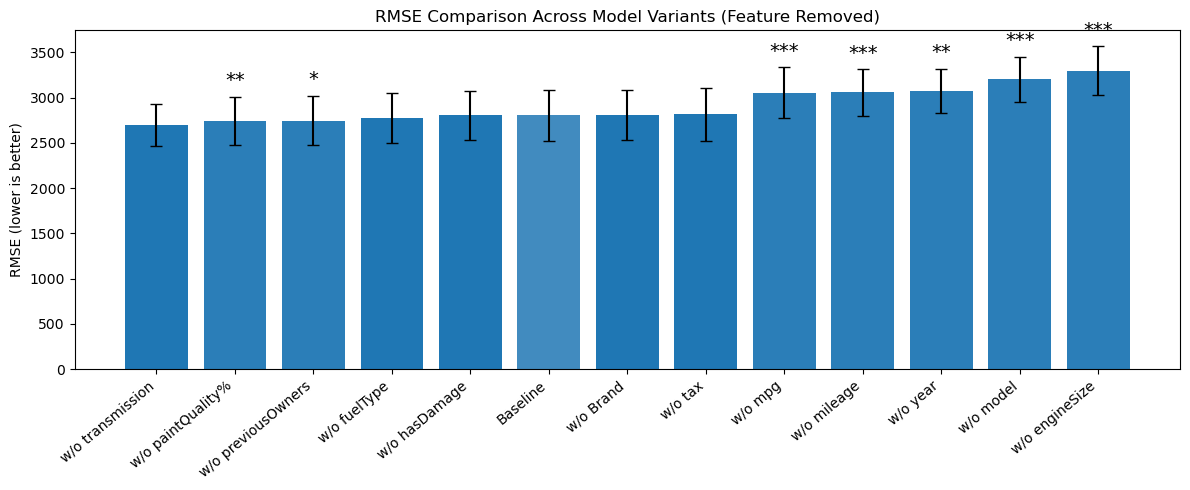

Saved: results/ablation/plots\rmse_comparison.png


In [7]:
# -----------------------
# Plot 1: RMSE comparison across variants
# -----------------------
plot_df = stats_df.copy()
plot_df = plot_df.sort_values("rmse_mean", ascending=True)

x = np.arange(len(plot_df))
means = plot_df["rmse_mean"].values
errs = plot_df["rmse_std"].values

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(x, means, yerr=errs, capsize=4)

# color baseline and significant
for i, (mv, bar) in enumerate(zip(plot_df["model_variant"], bars)):
    if mv == BASELINE_NAME:
        bar.set_alpha(0.85)
    else:
        p_adj, sig = sig_lookup.get(str(mv), (np.nan, False))
        if sig:
            bar.set_alpha(0.95)

ax.set_title("RMSE Comparison Across Model Variants (Feature Removed)")
ax.set_ylabel("RMSE (lower is better)")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model_variant"], rotation=40, ha="right")

# add stars above significant bars
ymax = np.nanmax(means + np.nan_to_num(errs, nan=0.0))
for i, mv in enumerate(plot_df["model_variant"]):
    p_adj, sig = sig_lookup.get(str(mv), (np.nan, False))
    s = p_to_stars(p_adj) if sig else ""
    if s:
        ax.text(i, means[i] + (errs[i] if np.isfinite(errs[i]) else 0) + 0.02*ymax, s,
                ha="center", va="bottom", fontsize=14)

plt.tight_layout()
out = os.path.join(PLOTS_DIR, "rmse_comparison.png")
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)


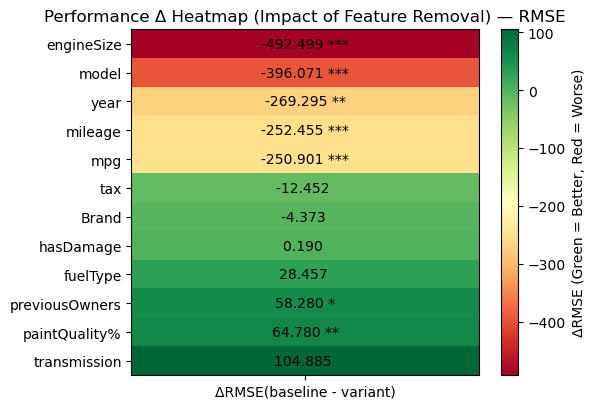

Saved: results/ablation/plots\delta_heatmap_rmse.png


In [9]:
# -----------------------
# Plot 2: Δ heatmap (Impact of Feature Removal) — RMSE only
# delta_rmse_mean = baseline - variant (positive better, negative worse)
# -----------------------
heat = stats_df[stats_df["model_variant"] != BASELINE_NAME].copy()
heat = heat.sort_values("delta_rmse_mean")  # most harmful (most negative) on top
vals = heat[["delta_rmse_mean"]].values

fig, ax = plt.subplots(figsize=(6, max(3, 0.35*len(heat))))
im = ax.imshow(vals, aspect="auto", cmap="RdYlGn", vmin=np.nanmin(vals), vmax=np.nanmax(vals))

ax.set_title("Performance Δ Heatmap (Impact of Feature Removal) — RMSE")
ax.set_yticks(np.arange(len(heat)))
ax.set_yticklabels(heat["features_removed"])
ax.set_xticks([0])
ax.set_xticklabels(["ΔRMSE(baseline - variant)"])

# annotate values and stars
for i in range(len(heat)):
    mv = str(heat.iloc[i]["model_variant"])
    p_adj, sig = sig_lookup.get(mv, (np.nan, False))
    stars = p_to_stars(p_adj) if sig else ""
    ax.text(0, i, f"{vals[i,0]:.3f} {stars}", ha="center", va="center", fontsize=10, color="black")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("ΔRMSE (Green = Better, Red = Worse)")

plt.tight_layout()
out = os.path.join(PLOTS_DIR, "delta_heatmap_rmse.png")
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)


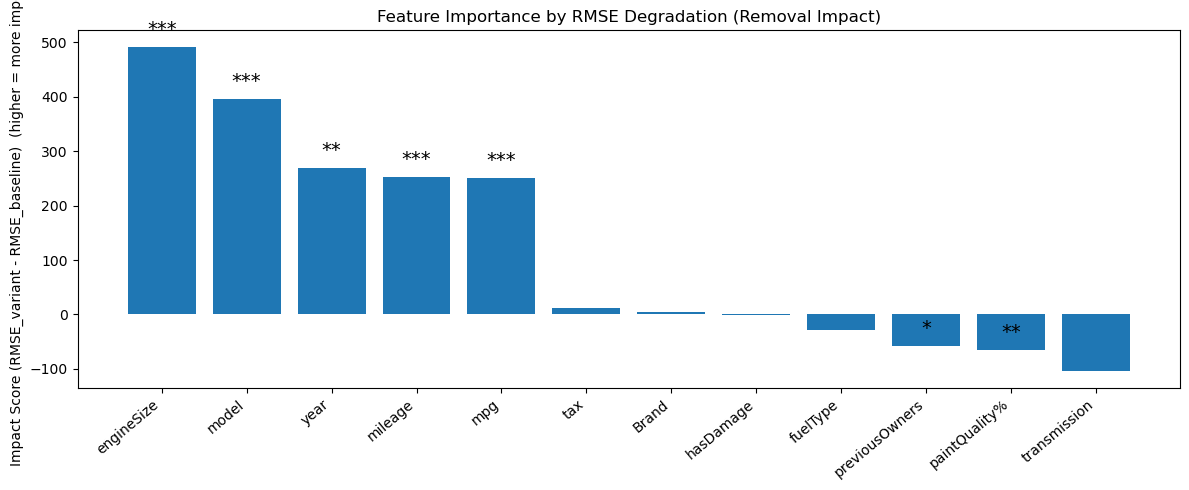

Saved: results/ablation/plots\feature_importance_rmse.png


In [10]:
# -----------------------
# Plot 3: Feature importance (impact_score)
# impact_score = variant_rmse_mean - baseline_rmse_mean (higher = worse removal => more important)
# -----------------------
imp_plot = imp_rank_out.copy()
imp_plot = imp_plot.sort_values("impact_score", ascending=False)

x = np.arange(len(imp_plot))
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(x, imp_plot["impact_score"].values)

ax.set_title("Feature Importance by RMSE Degradation (Removal Impact)")
ax.set_ylabel("Impact Score (RMSE_variant - RMSE_baseline)  (higher = more important)")
ax.set_xticks(x)
ax.set_xticklabels(imp_plot["features_removed"], rotation=40, ha="right")

ymax = np.nanmax(imp_plot["impact_score"].values) if len(imp_plot) else 1.0
for i, row in imp_plot.iterrows():
    s = p_to_stars(row["p_value_adj"]) if bool(row["significant"]) else ""
    if s:
        ax.text(i, row["impact_score"] + 0.03*ymax, s, ha="center", va="bottom", fontsize=14)

plt.tight_layout()
out = os.path.join(PLOTS_DIR, "feature_importance_rmse.png")
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)


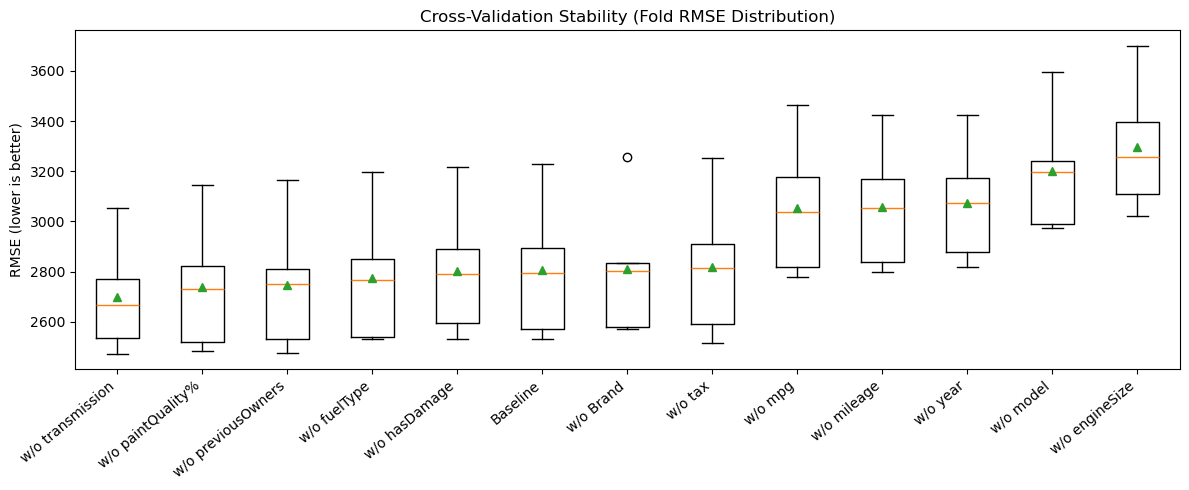

Saved: results/ablation/plots\cv_stability_rmse.png


In [11]:
# -----------------------
# Plot 4: CV stability (boxplot of fold RMSE per variant)
# -----------------------
order = (stats_df.sort_values("rmse_mean", ascending=True)["model_variant"].tolist())
data = [results_df.loc[results_df["model_variant"] == mv, "rmse"].dropna().values for mv in order]

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(data, labels=order, showmeans=True)
ax.set_title("Cross-Validation Stability (Fold RMSE Distribution)")
ax.set_ylabel("RMSE (lower is better)")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
out = os.path.join(PLOTS_DIR, "cv_stability_rmse.png")
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)


In [12]:
# -----------------------
# Plot 5: Summary table (top harmful removals + significance)
# -----------------------
summary = imp_df.copy()
summary = summary.sort_values("impact_score", ascending=False)

show_cols = [
    "model_variant", "features_removed", "rmse_mean", "rmse_std",
    "delta_rmse_mean", "impact_score", "p_value_adj", "significant"
]
summary_out = summary[show_cols].reset_index(drop=True)
summary_out.head(15)


,model_variant,features_removed,rmse_mean,rmse_std,delta_rmse_mean,impact_score,p_value_adj,significant
0,w/o engineSize,engineSize,3296.737031,267.463029,-492.498834,492.498834,0.000047,True
1,w/o model,model,3200.308903,251.995953,-396.070707,396.070707,0.000238,True
2,w/o year,year,3073.533433,243.295806,-269.295236,269.295236,0.001161,True
3,w/o mileage,mileage,3056.693658,255.733795,-252.455462,252.455462,0.000601,True
4,w/o mpg,mpg,3055.138719,280.181875,-250.900523,250.900523,0.000057,True
5,w/o tax,tax,2816.690373,291.733883,-12.452177,12.452177,0.535911,False
6,w/o Brand,Brand,2808.611430,279.468537,-4.373234,4.373234,1.000000,False
7,Baseline,none,2804.238196,281.816433,0.000000,0.000000,NaN,False
8,w/o hasDamage,hasDamage,2804.048388,271.798812,0.189808,-0.189808,1.000000,False
9,w/o fuelType,fuelType,2775.781370,273.167973,28.456826,-28.456826,0.070827,False


## Conclusions and Insights




These plots summarize how much each feature matters by measuring the **RMSE change when that feature is removed** (baseline vs “w/o feature”). Since **RMSE is lower-is-better**, any variant with higher RMSE than baseline is worse.

### 1) RMSE Comparison (bar chart)
The baseline sits around ~2800 RMSE, and the “w/o feature” variants split clearly into three groups:

- **Strongly harmful removals (largest RMSE increase, statistically significant):**
  - **engineSize** (worst)
  - **model**
  - **year**
  - **mileage**
  - **mpg**
  
  These removals consistently push RMSE well above baseline and are marked significant (stars), meaning the degradation is not random noise.

- **Near-neutral removals (small/no RMSE change, non-significant):**
  - **tax**, **Brand**, **hasDamage**, **fuelType**
  
  These sit close to baseline and are mostly non-significant, suggesting limited incremental value *in this model and data*.

- **Removals that appear to help (RMSE decreases):**
  - **transmission**
  - **paintQuality%**
  - (in some views) **previousOwners**
  
  These reduce RMSE relative to baseline, suggesting they may introduce noise, weak signal, or interactions not captured well by the current pipeline.

---

### 2) ΔRMSE Heatmap + Feature-Importance by RMSE degradation
Both of these plots tell the same story, just in different formats:

- **Most important features (removing them hurts RMSE the most):**
  1. **engineSize**
  2. **model**
  3. **year**
  4. **mileage**
  5. **mpg**

  These have the largest negative ΔRMSE (baseline − variant becomes strongly negative), meaning the variant is much worse than baseline. They’re also significant, reinforcing that they are truly important.

- **Low-impact / “safe to drop” candidates (close to zero impact, non-significant):**
  - **tax**, **Brand**, **hasDamage**  
  These have very small ΔRMSE magnitude and no strong statistical evidence of harm.

- **Potentially harmful to keep (removing improves RMSE):**
  - **transmission**, **paintQuality%** (and possibly **previousOwners**)  
  Since removal improves performance, these are candidates to investigate: they could be noisy, poorly encoded, sparse, or interacting in a way that hurts generalization.

> Important: “feature removal improves RMSE” does **not** prove the feature is useless in general — it may indicate issues in preprocessing/encoding, leakage risk, or interactions the model isn’t handling well.

---

### 3) Cross-Validation Stability (boxplots of fold RMSE)
The stability plot confirms that the differences aren’t just coming from one lucky fold:

- Variants like **w/o engineSize**, **w/o model**, **w/o year**, **w/o mileage**, **w/o mpg** show **consistently higher fold RMSE distributions** than baseline (boxes shifted upward).  
  This matches the significance results: the degradation is systematic.

- The “near-neutral” features (e.g., **tax**, **Brand**, **hasDamage**) show distributions overlapping baseline heavily, supporting the idea that their contribution is small or unstable.

- The variants that “help” (e.g., **w/o transmission**, **w/o paintQuality%**) show fold distributions shifted downward vs baseline, suggesting the improvement is consistent across folds (not just a one-off).

---

## Final takeaways (clear and actionable)
1. **Core drivers of performance (must-keep):**  
   **engineSize, model, year, mileage, mpg** — removing any of these causes a large and statistically significant RMSE increase.

2. **Low incremental value features (candidates to drop or re-check):**  
   **tax, Brand, hasDamage, fuelType** — small/non-significant impact in this pipeline.

3. **Features that may be hurting generalization (investigate):**  
   **transmission, paintQuality%, previousOwners** — removal improves RMSE, suggesting noise, encoding issues, or interactions. These are worth revisiting (encoding, missingness handling, or regularization) before deciding to keep them.

Overall importance pattern (RMSE-based):  
**engineSize > model > year > mileage ≈ mpg >> (tax, Brand, hasDamage, fuelType)**, with **transmission/paintQuality%** looking like potential noise sources in the current setup.
